# 0.  Introduction to PlatoSim

Welcome to PlatoSim! In this introductory tutorial we show how you can get started generating simulations with PlatoSim. Furthermore, we give an overview of all the utilties and help functions that are build into PlatoSim to help you getting started - enjoy!


<img src="../../figures/LogoPlatoSim.png" width="750"/>

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [2]:
import os

# PlatoSim
from platosim.utilities    import getFunctions
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

---
## 0.1 - Setup and run a simulation
---

As part of the installation of PlatoSim the project directory and working directory should already have been set. We don't need these paths for this series of tutorials, however, they are very handy when you start to create your own scripts. Thus check that these are globally defined (and if not, please first export them before continuing):

In [3]:
homeDir = os.getenv('PLATO_PROJECT_HOME')
workDir = os.getenv('PLATO_WORKDIR')
print(homeDir)
print(workDir)

/lhome/nicholas/software/PlatoSim3
/lhome/nicholas/software/workdir/


First we define the input/output (I/O) paths and files needed for PlatoSim:

In [4]:
# We use the default YAML input file and configure is later
inputDir  = homeDir + "/inputfiles"
inputFile = inputDir + "/inputfile.yaml"

# Save all output to current working directory
outputDir = os.getcwd()

Now a simulation object `sim` can be created using the class `Simulation`:

In [5]:
# Set up a Simulation object
outputFileName = "output_example1"
sim = Simulation(outputFileName, inputFile, outputDir=outputDir)

Note that you can set the output directory afterwards as well using 

```
sim.outputDir = outputDir
```

Also if not specified, the `inputfile.yaml` configuration file from the `PLATO_PROJECT_HOME/inputfiles` directory will be used (provided you have exported the `PLATO_PROJECT_HOME` environment variable). It is also possible to parse an absolute path to your own YAML input file as follows: 

```
sim.readConfigurationFile(<full/path/to/configuration/file>)
```

However, for both parameters, choose only one method since setting both will crash PlatoSim upon execution.

For now we use the default YAML settings to run our simulation. Note that by default PlatoSim does not overwrite the output from a previous simulation defined by the same name. To avoid that PlatoSim will raise an error message, we here activate the `removeOutputFile` option when launching PlatoSim. Furthermore you can trace the execution time activating the parameter `executionTime` as done here: 

In [6]:
# Run PlatoSim
simFile = sim.run(removeOutputFile=True, executionTime=True)

Execution time : 0:00:02.045060 [hh:mm:ss]


**Congratulations, you have a now generated your first PlatoSim simulation with Python!**

In this directory, the following information will be stored when running the simulation:
- `<runName>.yaml`: copy of the input file with the chosen configuration parameters (copied from the reference configuration file and possibly modified, as shown below);
- `<runName>.hdf5`: resulting exposures (images, PSF, etc.);
- `<runName>.log`: log file (to report any problems).


---
## 0.2 - Configuring the YAML input file
---

We note that all the configuration parameters in the YAML input file is the topic of the following tutorial: **01_ConfigurationParametersYAML**. Now say that we want to configure the input parameters but we don't want to open up the YAML input file to do so (e.g. because we want to make an automated script for our simulations). Again first we create a simulation object:

In [7]:
# Initialise PlatoSim
outputFileName = "output_example2"
sim = Simulation(outputFileName, outputDir=outputDir)

Since we are persistent and really don't want to open the YAML file manually, let's have a look at it's content from within Python. You can do this using the `Simulation.showYamlConfiguration()` function directly: 

In [8]:
# Open and print content
sim.showYamlConfiguration()

CCD:
  BFE:
    CoefficientsFileName: inputfiles/a_bfe.hdf5
  CTI:
    Model: Short2013
    Short2013:
      Beta: 0.37
      NumTrapSpecies: 4
      ReleaseTime:
        - 0.000237
        - 0.0243
        - 0.00203
        - 0.14
      Temperature: 203.0
      TrapCaptureCrossSection:
        - 2.46e-20
        - 1.74e-22
        - 7.05e-23
        - 2.45e-23
      TrapDensity:
        BOL:
          - 0.0
          - 0.0
          - 0.0
          - 0.0
        EOL:
          - 9.8
          - 3.31
          - 1.56
          - 13.24
    Short2013FromFile:
      CTIFileName: inputfiles/ctiInput.hdf5
    Simple:
      MeanCTE: 0.99999
  ChargeInjection:
    FirstRow: 50
    InjectionLevel: 90.0
    RowInterval: 100
  Contamination:
    MolecularContaminationEfficiency: 0.9573
    ParticulateContaminationEfficiency: 0.972
  DarkSignal:
    DSNU: 15.0
    DarkCurrent: 1.2
    Stability: 5.0
  DigitalSaturation: 65535
  FirstRowExposed: 0
  FlatfieldNoiseRMS: 0.01
  FullWellSaturation: 90

Note that the output (of `pyaml`) shown here is alphabetically ordered, however, the real YAML input file has a different structure (so don't panic). After an overview of the input parameters let's assume we want to change the following parameters:

In [9]:
# Observation
sim["ObservingParameters/NumExposures"] = 10

# Sky
sim["Sky/SkyBackground/UseConstantSkyBackground"] = True
sim["Sky/SkyBackground/BackgroundValue"]          = -1
sim["Sky/Cosmics/CosmicHitRate"]                  = 10

# Subfield
sim["SubField/NumColumns"]      = 300
sim["SubField/NumRows"]         = 300
sim["SubField/ZeroPointColumn"] = 0
sim["SubField/ZeroPointRow"]    = 0

We have chosen to simulate only 10 image, set the sky background to be estimated from an automatic tabulation according to the sky location (done with the `-1` flag), and we reduced the cosmic ray hit rate to "quiet" space weather conditions for PLATO (according to the results of the PLATO working groups). The subfield is enlarged but we keep the simulation in the origin of the CCD.

To gain the full control over what is being saved to the HDF5 output file (without the need to open the input YAML file), you can manually set all entries in the `Simulation.ControlHDF5Content` to `no` (or `False`). However, for must use cases you are only interested in saving a few of these since the more that is saved to the HDF5, the higher the execution time for PlatoSim. Thus, a more efficient way is to specifically *turn off* the writing of all outputs using the function `Simulation.turnOffAllOutput()` (and opposite you can *turn on* the writing of all output using `Simulation.turnOnAllOutput()`) and then activate the writing of the entries you are intered in. Say we only want to save the pixel maps and star positions:

In [10]:
# Turn off saving 
sim.turnOffAllOutput()

# Control HDF5
sim["ControlHDF5Content/WritePixelMaps"]     = True
sim["ControlHDF5Content/WriteStarPositions"] = True

If you are ever in doubt of which parameters that will/or are saved to the HDF5 output file, you can make a simple check using the function `Simulation.showAllOutput()` as done here:

In [11]:
sim.showAllOutput()

ControlHDF5Content/GroupByExposure = False
ControlHDF5Content/WritePixelMaps = True
ControlHDF5Content/WriteBiasMaps = False
ControlHDF5Content/WriteSmearingMaps = False
ControlHDF5Content/WriteFlatfieldMap = False
ControlHDF5Content/WriteThroughputMaps = False
ControlHDF5Content/WriteTransmissionEfficiency = False
ControlHDF5Content/WriteBackgroundMap = False
ControlHDF5Content/WriteCTI = False
ControlHDF5Content/WriteSubPixelImages = False
ControlHDF5Content/WriteDiffusedPSF = False
ControlHDF5Content/WriteHighResolutionPSF = False
ControlHDF5Content/WriteACS = False
ControlHDF5Content/WriteTelescopeACS = False
ControlHDF5Content/WriteStarCatalog = False
ControlHDF5Content/WriteStarPositions = True
ControlHDF5Content/WriteGhostPositions = False
ControlHDF5Content/WriteCosmics = False


Let's run the simulation:

In [12]:
# Run PlatoSim
simfile = sim.run(removeOutputFile=True)

---
## 0.3 - Fetching the HDF5 output file
---

To access the HDF5 output file that contains your simulated data, you have two choices: 

  1. use the above `sim` object returned when running a simulation, or 
  2. you can simply use the `SimFile` class which fetch a copy of the `sim` object. 

The second option is often desired since your simulation(s) potentially takes quite a while to run and you may want to fetch the simulation(s) at a later stage as well. Hence below we show how to retrieve the HDF5 output using the `SimFile` class:

In [13]:
# Fetch HDF5 output
f = SimFile("output_example2.hdf5")

---
## 0.4 - Plot the simulated subfield
---

Plotting your simulated pixel images can be done out-of-the-box using the `SimFile.showImage()` utility of the `SimFile` class. This function can either plot a specific frame using `imageNr` or the entire image cube (if more than one exposure is simulated) with an interactive slider:

<IPython.core.display.Javascript object>


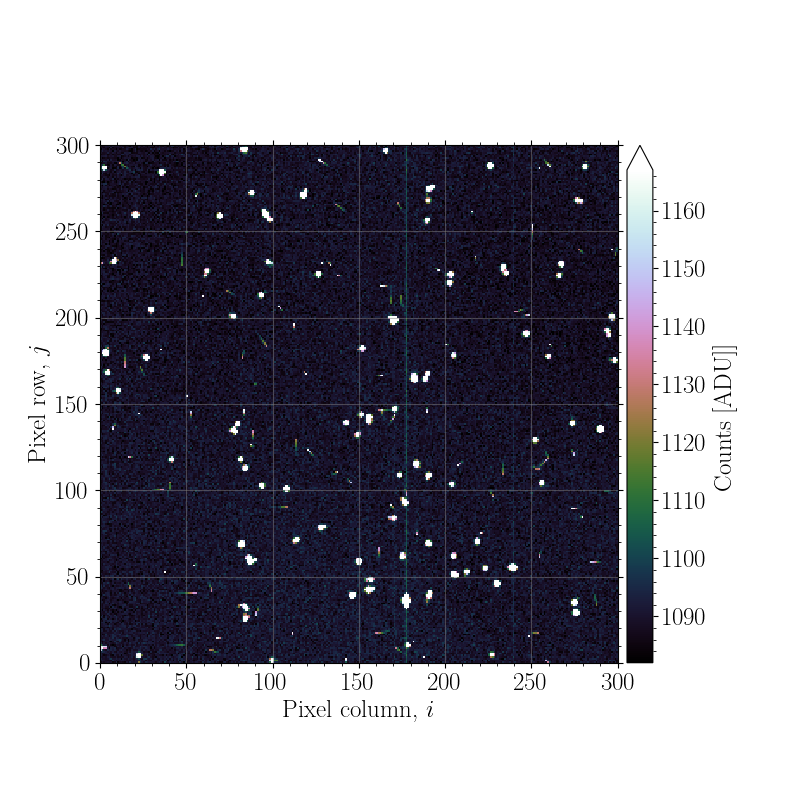

interactive(children=(IntSlider(value=0, description='Image:', layout=Layout(width='70%'), max=9), Output()), …

In [14]:
fig, ax = f.showImage(imageNr=False, imgScale="percentile", clip=1,  
                      figsize=(8,8), fontSize=18, useTitle=False,
                      showStarPositions=False, showStarIDs=False,
                      colorMap="cubehelix", colorBar=True, showGrid=True) 

---
## 0.5 - Overview of PlatoSim's help functions
---

We have now covered the basics of using PlatoSim within a Python interface. The following is an overview of all the help functions and utilities that are directly build into the PlatoSim software package to ease your life of running, analyzing, and exploring your simulations. Below each Python class or script is a file located in the `PlatoSim3/python/platosim/` directory. Notice that an exploration of the following Python classes is integrated into the topics of the following tutorials.

### Class functions

The `Simulation` class contains functions to **setup and launch PlatoSim** and is the cornorstone of running simulations:

In [15]:
getFunctions(Simulation)

Simulation functions
__contains__
__getitem__
__init__
__setitem__
__str__
controlAllEffects
createDetectorTemperatureFile
createDirectory
createDriftFile
createPhotometryFile


The `SimFile` class contains functions to **retrieve, plot, and save information** about your simulations:

In [16]:
getFunctions(SimFile)

SimFile functions
__del__
__init__
checkPhotometry
getApertureMask
getBackground
getBiasMapLeft
getBiasMapRight
getCoordinates
getCosmicsAffectedExposures
getCosmicsAffectedPixels


The `Distribution` class contains **star catalogues functions** to generate custom stellar catalogues:

In [17]:
from platosim.distribution import Distribution
getFunctions(Distribution)

Distribution functions
__del__
__init__
expFunction
getMagnitudeDistribution
getRandomMagnitude
getRandomPosition
getStarCatalog
inverseExpFunction
readMagnitudes


### Utility functions

The `h5` utility contains **HDF5 information tracking** to help fetching information about your simulated output files:

In [18]:
import platosim.h5 as h5
getFunctions(h5)

platosim.h5 functions
fileMatch
h5get
h5ls
h5paths


The `referenceFrames` utility contains **coordinate transformations** that are used internally by PlatoSim and may may be useful for making your own scripts:

In [19]:
import platosim.referenceFrames as rf 
getFunctions(rf)

platosim.referenceFrames functions
calculateSubfieldAroundCoordinates
computeCCDcornersInFocalPlane
distortedToUndistortedFocalPlaneCoordinates
ecliptic2equatorial
eprint
equatorial2ecliptic
focalPlaneAngles2pixelCoordinates
focalPlaneCoordinatesFromGnomonicRadialDistance
focalPlaneToPixelCoordinates
focalPlaneToSkyCoordinates


The `plot` utility contains **plot functions** that can help you quickly visualise your inputs and outputs:

In [20]:
import platosim.plot as pt
getFunctions(pt)

platosim.plot functions
compass
discretizeColorbar
drawCCDsInCameraFocalPlane
drawCCDsInFocalPlane
drawCCDsInSkyMollweide
drawPixelInFocalPlane
drawStarInCCDfocalPlane
drawStarInFocalPlane
drawStarsInSkyAitoff
drawStarsInSkyMollweide


The `utilities` utility contains **general help functions** that are used throughout PlatoSim's python functions:

In [21]:
import platosim.utilities as ut
getFunctions(ut)

platosim.utilities functions
compilation
convertMagnitudeRange
convertQuarterRange
copyInputYAML
cumtrapz
diff
downloadFromFTP
errorcode
evalLinReg
fileMatch


The `noise` utility contains **random and systematic noise functions** to generate synthetic but realistic input files and hardware alignment models:

In [22]:
import platosim.noise as ns
getFunctions(ns)

platosim.noise functions
errorcode
getACS
getAPE
getDataGaps
getGain
getPRE
getRedNoise
getTED
latex
modelRedNoise
